## Pandas analysis

This exercise consists in analyzing a dataset containg timing information from a series of Time-to-Digital-Converters (TDC) implemented in a couple of FPGAs. Each measurement (i.e. each row of the input file) consists of a flag that specifies the type of message ('HEAD', which in this case is always 1), two addresses of the TDC providing the signal ('FPGA' and 'TDC_CHANNEL'), and the timing information ('ORBIT_CNT', 'BX_COUNTER', and 'TDC_MEAS'). Each TDC count corresponds to 25/30 ns, whereas a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER. This allows to store the time in a similar way to hours, minutes and seconds.

In [1]:
# If you didn't download it yet, please get the relevant file now!
!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt -P ~/data/

--2025-11-27 09:10:33--  https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6025:18::a27d:4512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/pkkpoxlm7beasryexpdf8/data_000637.txt?rlkey=rkm2em1v57hewglzelmin21c9 [following]
--2025-11-27 09:10:33--  https://www.dropbox.com/scl/fi/pkkpoxlm7beasryexpdf8/data_000637.txt?rlkey=rkm2em1v57hewglzelmin21c9
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc3c7897d5f2331a5e873295d4e4.dl.dropboxusercontent.com/cd/0/inline/C1_SPFSZGBUdzewyWFGq8MqDK63BsbpT9FU5h7mmmB7H-2rYmADuB2Hr37mxvuEXGR4kLXD4fdPyh0z7_M9LPK2ar92jbQUxfH5RfPa_COEdmOii7nLTO5ug_fxQaGpv-Hg/file# [following]
--2025-11-27 09:10:34--  https://uc3c7897d5f2331a5e873295d4e4.dl.dropboxusercontent.com/cd/0/inline/C1_SPFSZGB

1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

2\. Find out the number of BX in a ORBIT (the value 'x').

3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

6\. Create a new DataFrame that contains only the rows with HEAD=1.

7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

8\. Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

Number of rows for the entire file :
 1310721
DataFrame shape: (1300720, 6)
Head of Data frame with row from 10000 to  1310721  :
        HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS
10000     1     0           50  3869200267         776        22
10001     1     0           47  3869200267         785        14
10002     1     0           63  3869200267         921        28
10003     1     0           64  3869200267         924        15
10004     1     0            7  3869200267         998        22
x =  3564
The data tacking lasted:
 0.9626817425  seconds
Head of data frame with absolute time in ns :
 10000    3.447457e+14
10001    3.447457e+14
10002    3.447457e+14
10003    3.447457e+14
10004    3.447457e+14
Name: times, dtype: float64
Head of data frame wuth 'HEAD' set to 0 or 1 randomly :
 10000    0
10001    0
10002    0
10003    1
10004    1
Name: HEAD, dtype: int64
Head of data frame with 'HEAD' = 1 :
        HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_M

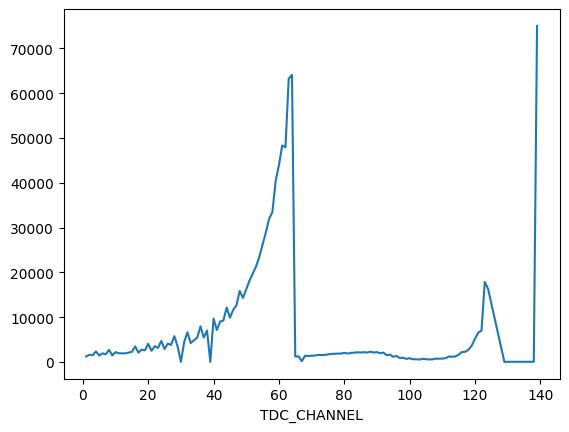

Head of data frame with 'FPGA' = 1 :
        HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS         times
10034     1     1           12  3869200267        1861        26  3.447457e+14
10035     1     1           14  3869200267        1861        19  3.447457e+14
10037     1     1            8  3869200267        2277         1  3.447457e+14
10038     1     1           10  3869200267        2283        12  3.447457e+14
10040     1     1           11  3869200267        2286        29  3.447457e+14


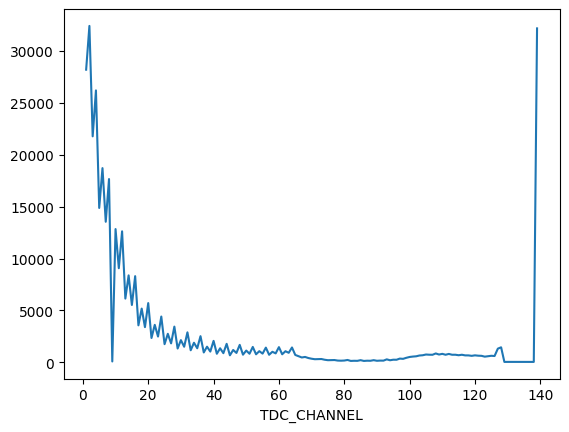

In [32]:
import numpy as np
import pandas as pd
import numpy.random as npr
import matplotlib.pyplot as plt

file_name="/home/elena/data/data_000637.txt.1"
with open(file_name, 'r') as f:
    count_row = 0
    for row in f:
        count_row += 1
print("Number of rows for the entire file :\n", count_row)
data=pd.read_csv(file_name)

#Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. 
#Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.
df = pd.DataFrame(data[10000:count_row])
print(f"DataFrame shape: {df.shape}")
print("Head of Data frame with row from 10000 to ", count_row, " :\n", df.head())

#Find out the number of BX in a ORBIT (the value 'x')
print ( "x = ", df['BX_COUNTER'].max(axis=0)+1) 

#Find out how much the data taking lasted. 
#You can either make an estimate based on the fraction of the measurements (rows) 
#you read, or perform this check precisely by reading out the whole dataset.
df['times']=df['TDC_MEAS']*25/30+df['BX_COUNTER']*25+df['ORBIT_CNT']*3564*25
print("The data tacking lasted:\n", (df.iloc[-1]['times'] - df.iloc[10000]['times'])*10**(-9), " seconds")

#Create a new column with the absolute time in ns 
#(as a combination of the other three columns with timing information).
print("Head of data frame with absolute time in ns :\n", df['times'].head())

#Replace the values (all 1) of the HEAD column randomly with 0 or 1.
df['HEAD'] = np.random.randint(0, 2, size=len(df))
print("Head of data frame wuth 'HEAD' set to 0 or 1 randomly :\n", df['HEAD'].head())

#Create a new DataFrame that contains only the rows with HEAD=1.
df_mask = df[df['HEAD'] == 1]
df_head = pd.DataFrame(df_mask.dropna(how = 'any'))
print("Head of data frame with 'HEAD' = 1 :\n", df_head.head())

#Make two occupancy plots (one for each FPGA), 
#i.e. plot the number of counts per TDC channel
df_mask_0 = df[df['FPGA'] == 0]
fpga_0 = df_mask_0.dropna(how = 'any')
print("Head of data frame with 'FPGA' = 0 :\n", fpga_0.head())
count_0 = fpga_0['TDC_CHANNEL'].value_counts() #conta quante volte appare ogni TDC_CHANNEL
count_0 = count_0.sort_index()
count_0.plot()
plt.show()

df_mask_1 = df[df['FPGA'] == 1]
fpga_1 = df_mask_1.dropna(how = 'any')
print("Head of data frame with 'FPGA' = 1 :\n", fpga_1.head())
count_1 = fpga_1['TDC_CHANNEL'].value_counts() #conta quante volte appare ogni TDC_CHANNEL
count_1 = count_1.sort_index()
count_1.plot()
plt.show()

#Use the groupby method to find out the noisy channels, 
#i.e. the TDC channels with most counts (say the top 3)


In [7]:
N = data['BX_COUNTER'].max(axis=0)
print(N)

3563


In [8]:
print ("The number of BX in a orbit is ", N+1)

The number of BX in a orbit is  3564


In [9]:
orbit_max = data['ORBIT_CNT'].max(axis=0)
BX_max = N
TDC_max = data['TDC_MEAS'].max(axis=0)
print (orbit_max)
print (BX_max)
print(TDC_max)

3869209011
3563
29


In [10]:
orbit_min = data['ORBIT_CNT'].min(axis=0)
BX_min = data['BX_COUNTER'].min(axis=0)
TDC_min = data['TDC_MEAS'].min(axis=0)
print (orbit_min)
print (BX_min)
print(TDC_min)

3869200167
0
0


In [ ]:
max_ns = 